In [1]:
%pwd
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)
    
import torch
import numpy as np
import torch.optim as optim
import json

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils

from configs.flower_curv_configs import all_configs
from scripts.experiment_utils import generate_experiment_report

In [3]:
torch.manual_seed(42)
np.random.seed(42)

----------------------------------------------------------------
Running exp00_flower_curve. Description: alpha=1.0, gamma=0.0, geodesic_distortion_amp=0.1, noise_var=0.001
----------------------------------------------------------------


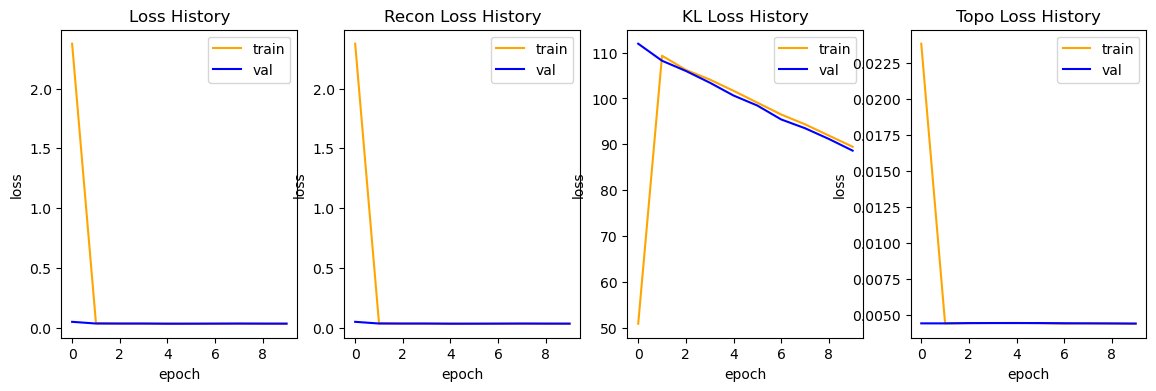

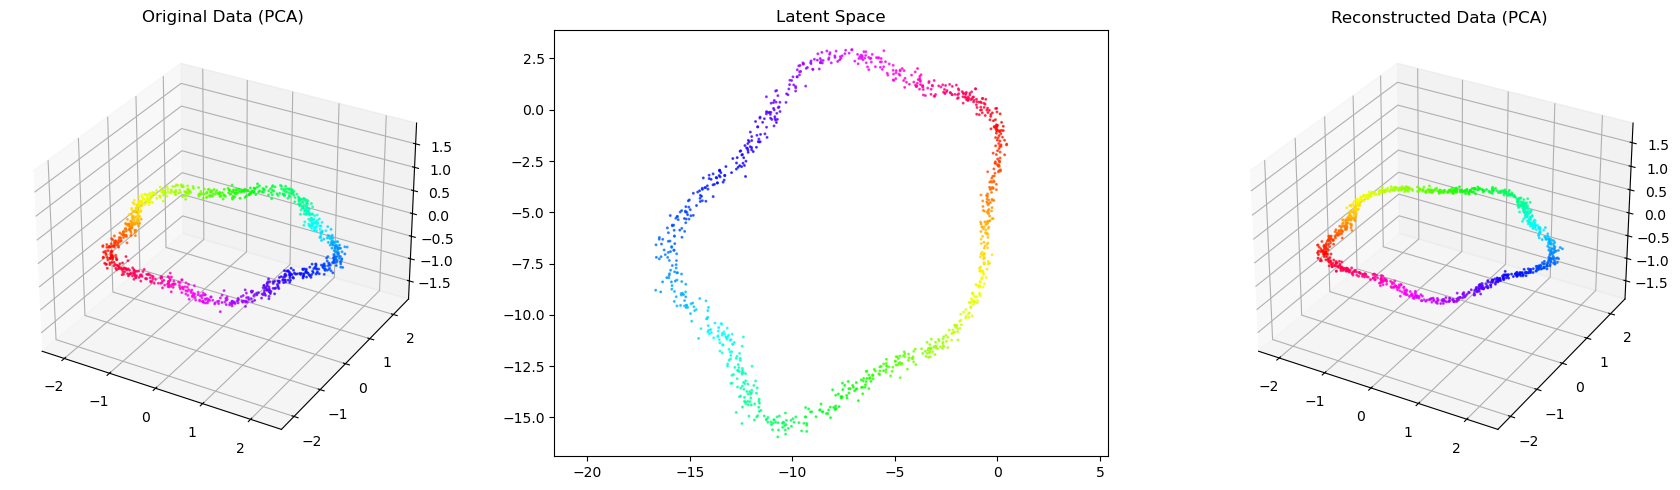

Estimating 1D curvature: 100%|██████████| 800/800 [00:00<00:00, 1147.18it/s]
Computing curvature from immersion  (Manifold Dim > 1): 100%|██████████| 800/800 [00:22<00:00, 35.20it/s]
Computing curvature from immersion (Manifold Dim = 1): 100%|██████████| 800/800 [00:21<00:00, 37.05it/s]


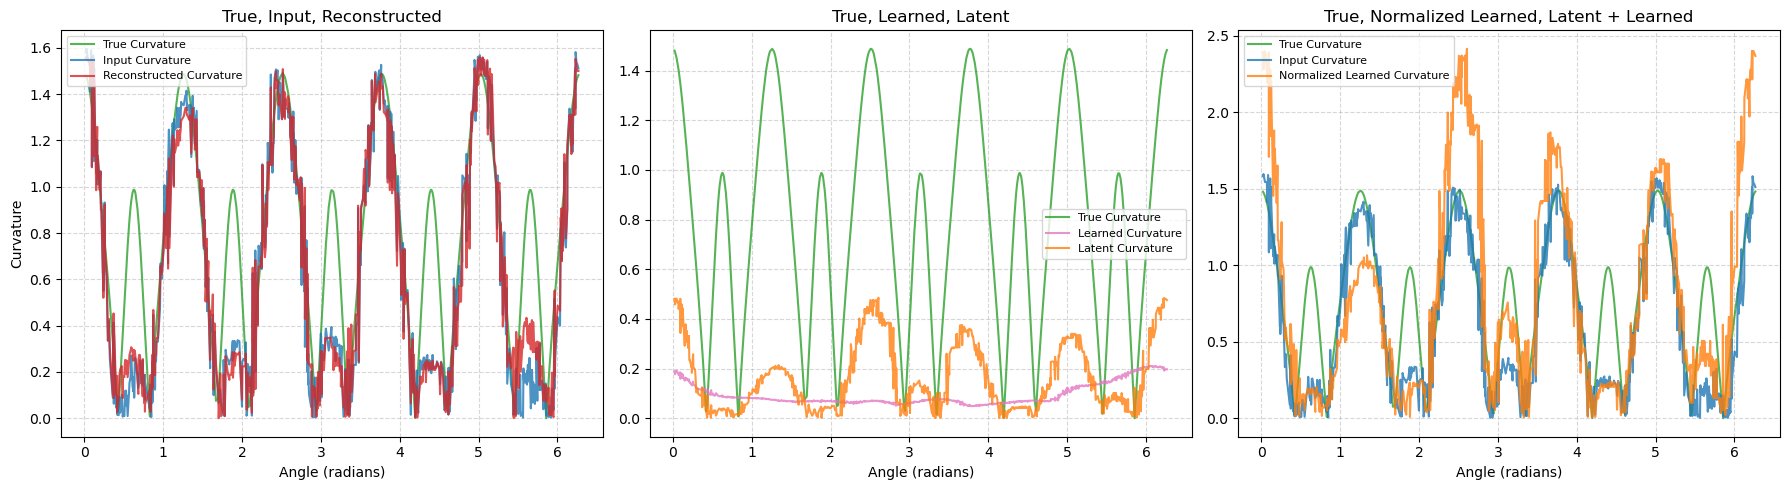

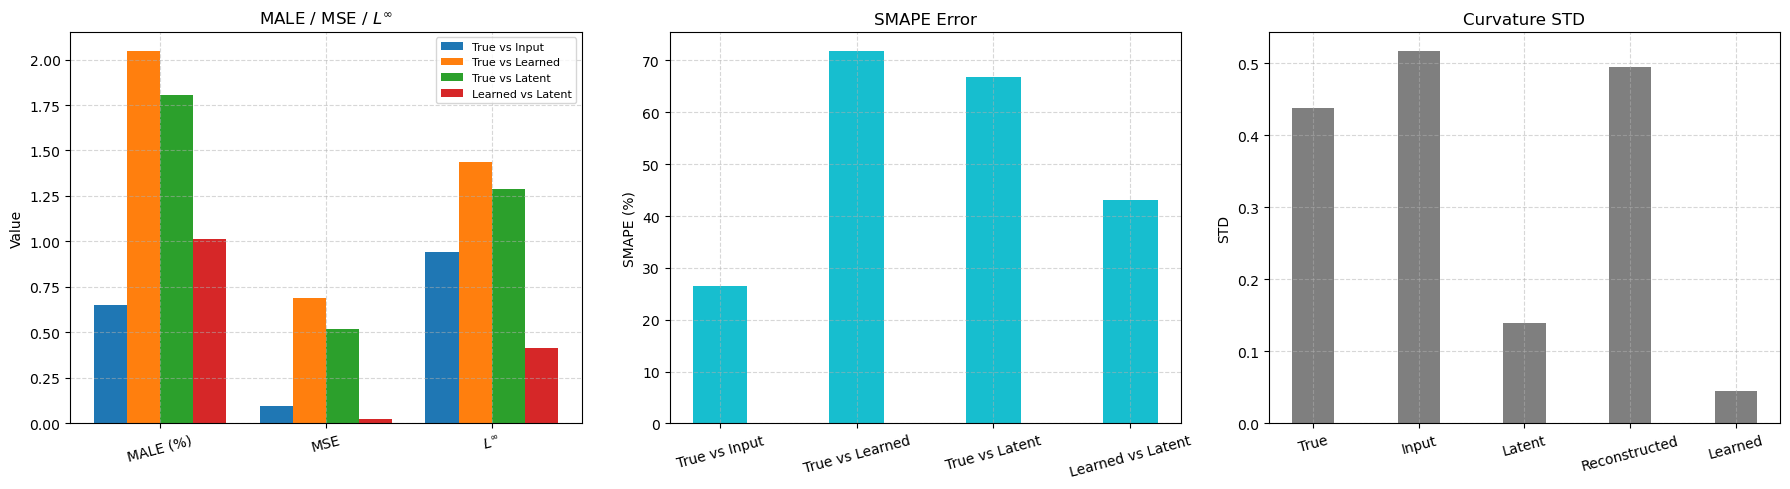

saving the config
defining path
loading images and json
open for writing
start writing
adding plots
adding jsons
----------------------------------------------------------------
Running exp01_flower_curve. Description: alpha=1.0, gamma=1.0, dim_topo_loss=0, geodesic_distortion_amp=0.1, noise_var=0.001
----------------------------------------------------------------


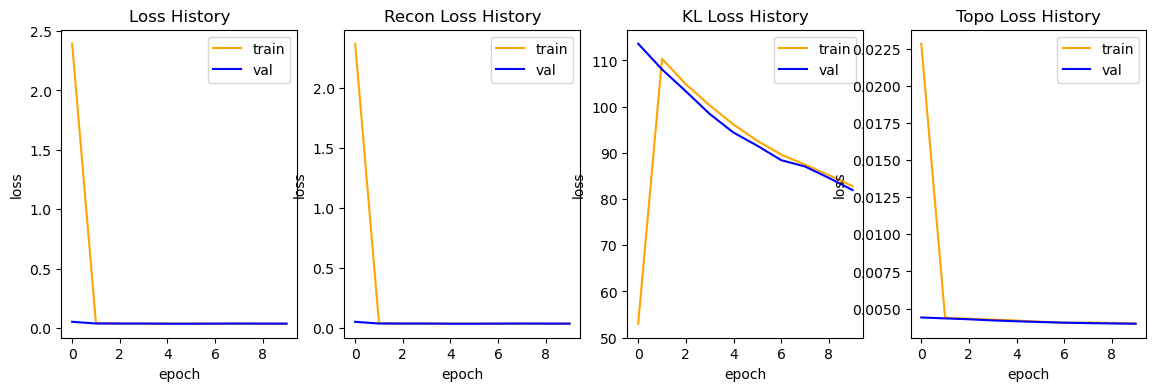

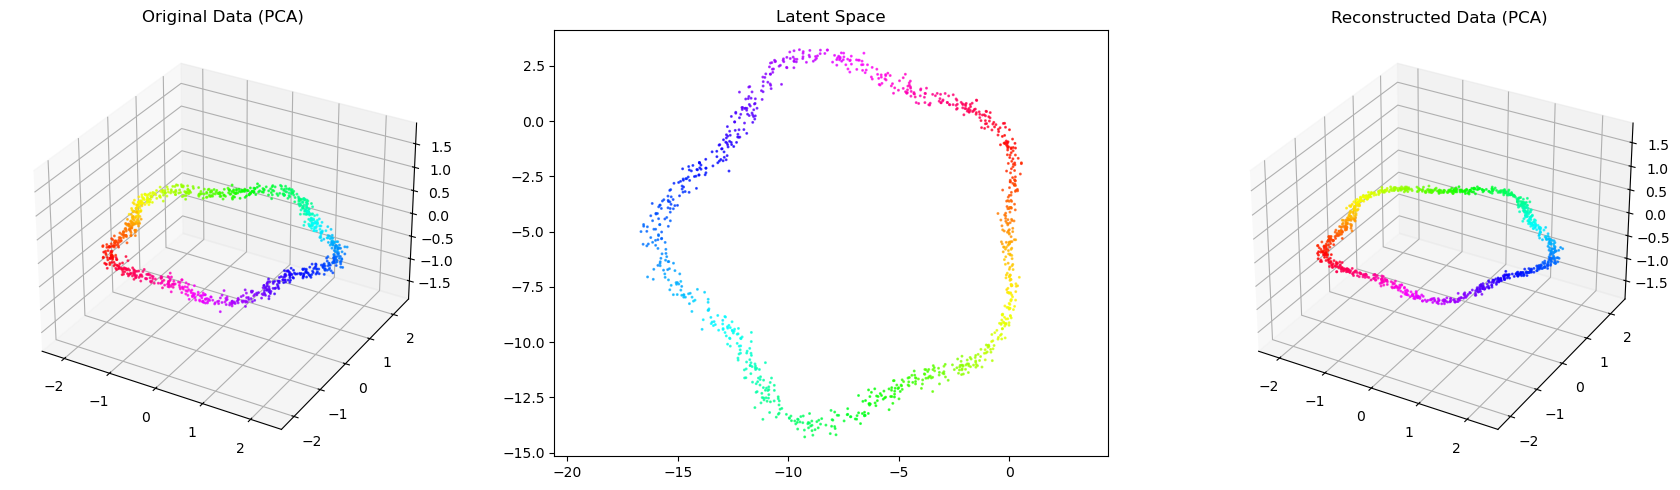

Estimating 1D curvature: 100%|██████████| 800/800 [00:00<00:00, 1321.53it/s]
Computing curvature from immersion  (Manifold Dim > 1): 100%|██████████| 800/800 [00:24<00:00, 32.70it/s]
Computing curvature from immersion (Manifold Dim = 1): 100%|██████████| 800/800 [00:27<00:00, 29.05it/s]


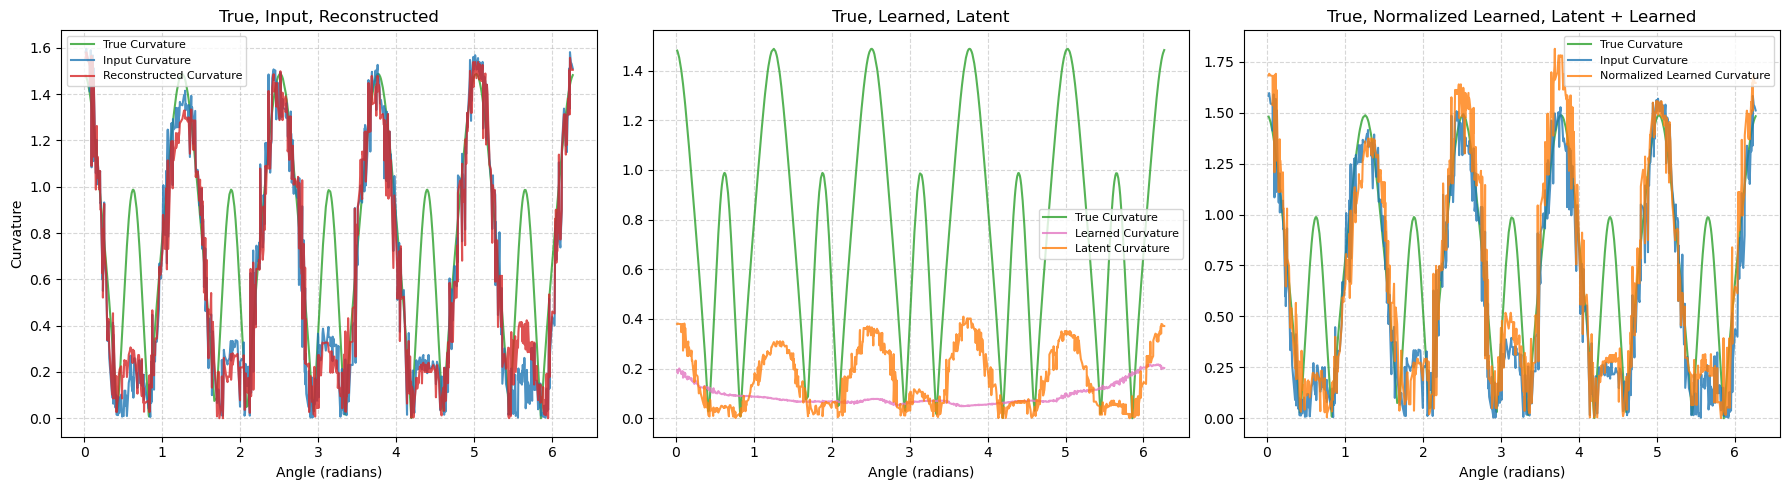

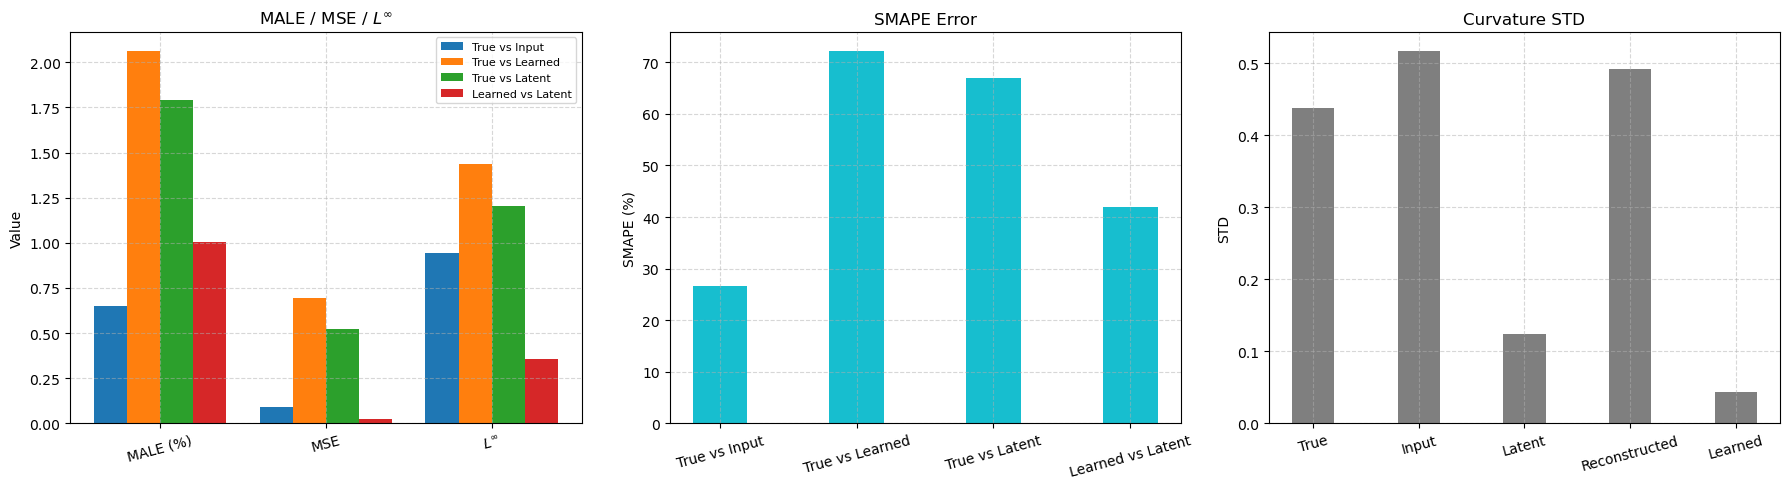

saving the config
defining path
loading images and json
open for writing
start writing
adding plots
adding jsons
----------------------------------------------------------------
Running exp02_flower_curve. Description: alpha=1.0, gamma=1.0, dim_topo_loss=1, geodesic_distortion_amp=0.1, noise_var=0.001
----------------------------------------------------------------


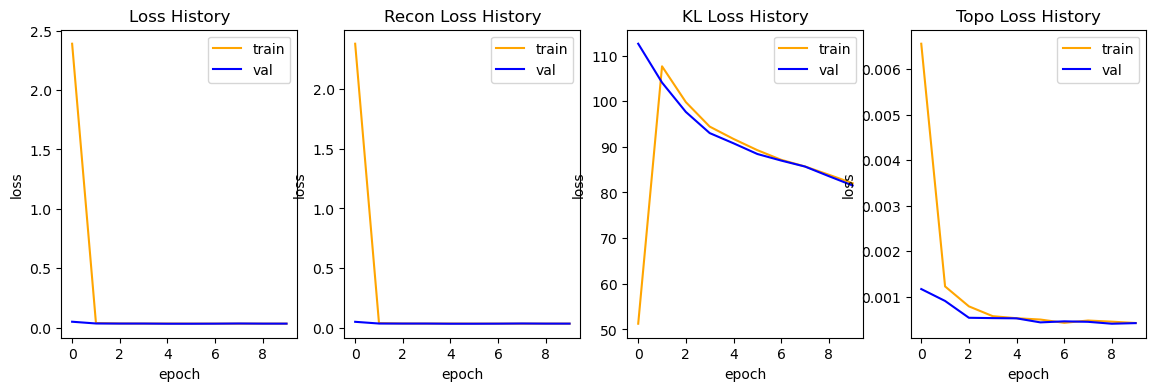

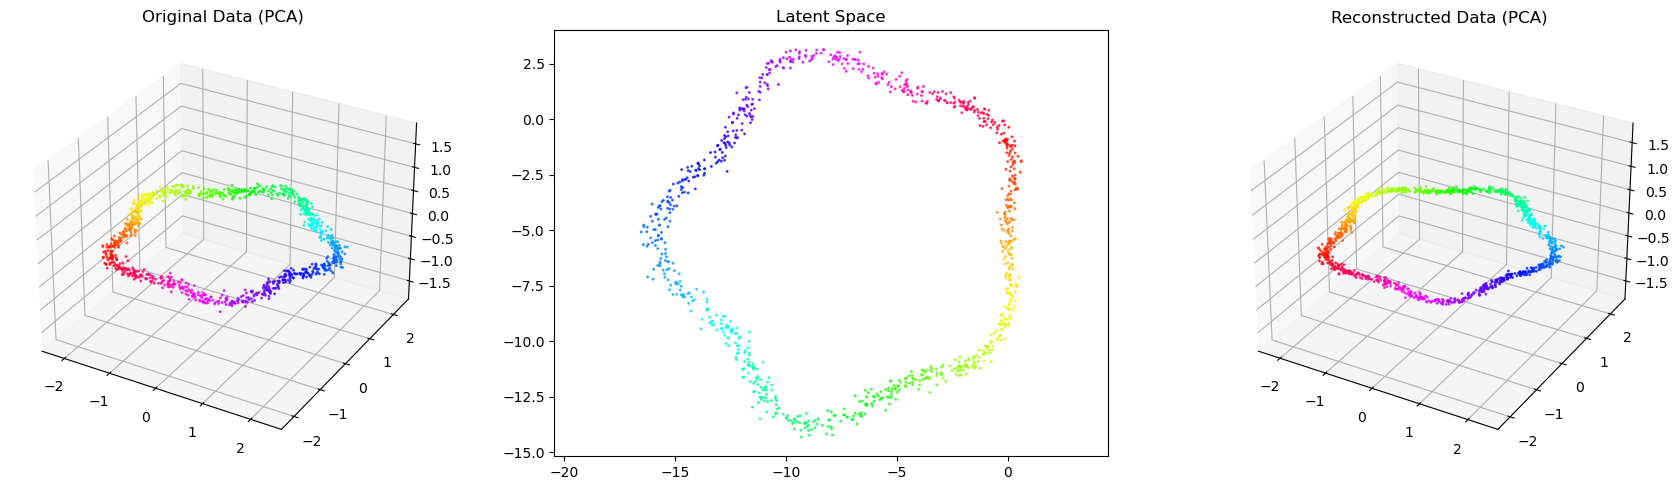

Estimating 1D curvature: 100%|██████████| 800/800 [00:00<00:00, 1228.94it/s]
Computing curvature from immersion  (Manifold Dim > 1):   6%|▌         | 44/800 [00:01<00:21, 35.67it/s]

In [ ]:
for name, config in all_configs.items():
    print("----------------------------------------------------------------")
    print(f"Running {name}. Description: {config.description}")
    print("----------------------------------------------------------------")
    
    data_loader = dataloader.load_synthetic_ds(config)
    train_loader, test_loader = data_loader
    vae_model = model.EuclideanVAE(config)
    optimizer = optim.Adam(vae_model.parameters(), lr=config.learning_rate)
    history = trainer.MVAETrainer(vae_model, data_loader, optimizer, config).train()
    utils.show_training_history(config, history)
    utils.plot_data_latents_recon(config, vae_model, test_loader)
    utils.plot_empirical_curvature(config=config, model=vae_model, data_loader=train_loader)
        
    generate_experiment_report(config)